# Imports

In [1]:
import sys
sys.path.insert(1, '../')

In [2]:
import os

In [3]:
import pandas as pd

In [4]:
import cv2

In [5]:
import matplotlib.pyplot as plt

In [6]:
import numpy as np

In [7]:
import json

In [8]:
import re

In [9]:
from utils.draw import draw_kp_on_image

In [10]:
from IPython.display import clear_output

In [11]:
import time

In [12]:
import copy

# Methods

In [13]:
def to_numpy(string):
    return np.asarray(json.loads(re.sub('\s+', ',',re.sub('\[\s+', '[', re.sub('\n\s+', ',', string)))))

In [14]:
def preprocess(img, kps, WIDTH=224, HEIGHT=224):
    kp = kps.copy()
    h, w = img.shape[:2]
    if w > h:
        pad = w - h
        img_by = w
    else:
        pad = h - w
        img_by = h
    top, bottom, left, right = 0, img_by, 0, img_by
    if w > h:
        top = int(np.ceil(pad/2)) + 1
        if pad > 1:
            bottom = img_by - int(np.floor(pad/2)) + 1
        else:
            top -= 1
    else:
        left = int(np.ceil(pad/2)) + 1
        if pad > 1:
            right = img_by - int(np.floor(pad/2)) + 1
        else:
            left -= 1
    new_img = np.zeros((img_by, img_by, 3)).astype('uint8')
    new_img[top:bottom, left:right, :] = img
    new_img = cv2.resize(new_img, (WIDTH, HEIGHT))
    resize_ratio = min((WIDTH/w), (HEIGHT/h))
    kp[:, 0] = (kp[:, 0] + left)*resize_ratio
    kp[:, 1] = (kp[:, 1] + top)*resize_ratio
    return new_img, kp, (left, top, resize_ratio)

In [15]:
to_int = lambda x: int(x)

In [16]:
def rgb(img):
    return img[...,::-1]

In [17]:
def plot_bbox(img, bbox):
    x1, y1, w, h = bbox

    x2, y2 = x1+w, y1+h

    p1 = (x1, y1)
    p2 = (x2, y1)
    p3 = (x1, y2)
    p4 = (x2, y2)

    bbox_img = cv2.line(img.copy(), p1, p2, color=(0,0,255), thickness=1)
    bbox_img = cv2.line(bbox_img, p2, p4, color=(0,0,255), thickness=1)
    bbox_img = cv2.line(bbox_img, p3, p4, color=(0,0,255), thickness=1)
    bbox_img = cv2.line(bbox_img, p1, p3, color=(0,0,255), thickness=1)

    return bbox_img

# Parameters

In [18]:
TRAINING_DIR = '/home/usman/datasets/coco/legs_train/cropped'

In [19]:
DIR_FOR_NEW_DATA = os.path.join(TRAINING_DIR, '224x224')
DIR_FOR_NEW_IMGS = os.path.join(DIR_FOR_NEW_DATA, 'data')

In [20]:
IMGS_DIR = os.path.join(TRAINING_DIR, 'one_person', 'data')

In [21]:
KP_PATH = os.path.join(TRAINING_DIR, 'one_person', 'keypoints.csv')

In [22]:
BBOX_PATH = os.path.join(TRAINING_DIR, 'one_person', 'bbox.csv')

# Load Data

In [23]:
keypoints_df = pd.read_csv(KP_PATH, index_col=0)
keypoints_df['keypoints'] = keypoints_df['keypoints'].apply(lambda x: to_numpy(x))
keypoints_df

,file_name,height,width,id,num_keypoints,iscrowd,keypoints,category_id,id_y
0,000000574769.jpg,225.0,117.0,574769.0,8.0,0.0,"[[120, 0, 0], [0, 30, 0], [87, 22, 2], [33, 20...",1.0,201078.0
1,000000483108.jpg,131.0,116.0,483108.0,8.0,0.0,"[[92, 0, 0], [23, 0, 0], [66, 20, 2], [38, 20,...",1.0,188213.0
2,000000463836.jpg,182.0,134.0,463836.0,8.0,0.0,"[[48, 21, 2], [98, 23, 2], [55, 23, 2], [88, 2...",1.0,441196.0
3,000000369826.jpg,76.0,104.0,369826.0,8.0,0.0,"[[15, 0, 0], [57, 0, 0], [30, 22, 2], [38, 20,...",1.0,1241029.0
4,000000291380.jpg,80.0,106.0,291380.0,8.0,0.0,"[[45, 0, 0], [7, 0, 0], [49, 20, 2], [30, 21, ...",1.0,219822.0
...,...,...,...,...,...,...,...,...,...
9950,000000019642.jpg,251.0,150.0,19642.0,8.0,0.0,"[[19, 0, 0], [26, 0, 0], [92, 21, 2], [33, 20,...",1.0,478315.0
9951,000000268909.jpg,237.0,144.0,268909.0,8.0,0.0,"[[0, 0, 0], [0, 0, 0], [109, 20, 2], [81, 23, ...",1.0,2161828.0
9952,000000049429.jpg,238.0,142.0,49429.0,8.0,0.0,"[[166, 0, 0], [0, 0, 0], [110, 26, 1], [30, 20...",1.0,468105.0
9953,000000250249.jpg,286.0,240.0,250249.0,8.0,0.0,"[[240, 3, 2], [140, 26, 2], [117, 20, 2], [30,...",1.0,456875.0


In [24]:
min_size = 100
keypoints_df.drop(keypoints_df[(keypoints_df['height'] < min_size) & (keypoints_df['width'] < min_size)].index, inplace=True)

In [25]:
keypoints_df.shape

(9105, 9)

In [26]:
bbox_df = pd.read_csv(BBOX_PATH, index_col=0)
bbox_df

,image_id,bbox,category_id
4198,574769.0,"[0, 0, 116, 224]",1.0
14136,574769.0,"[0, 145, 22, 80]",31.0
3881,483108.0,"[4, 0, 93, 127]",1.0
7876,463836.0,"[19, 0, 107, 170]",1.0
14027,463836.0,"[32, 0, 63, 15]",27.0
...,...,...,...
410027,250249.0,"[0, 0, 239, 285]",1.0
520413,250249.0,"[60, 0, 180, 115]",73.0
809121,250249.0,"[0, 242, 216, 44]",17.0
366684,294751.0,"[0, 8, 20, 256]",82.0


In [27]:
bbox_df = bbox_df[bbox_df['image_id'].isin(keypoints_df['id'])]

In [28]:
bbox_df['bbox'] = bbox_df['bbox'].apply(lambda x: np.asarray(json.loads(x)))

/tmp/ipykernel_29730/2206396555.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bbox_df['bbox'] = bbox_df['bbox'].apply(lambda x: np.asarray(json.loads(x)))


In [29]:
# min_size = 200
# df[(df['height'] >= min_size) | (df['width'] >= min_size)]

# Run Preprocessing

In [31]:
# del new_df, new_bbox_df

In [32]:
try:
    new_df
except:
    new_df = pd.DataFrame()
try:
    new_bbox_df
except:
    new_bbox_df = pd.DataFrame()
new_df.shape, new_bbox_df.shape

((0, 0), (0, 0))

In [33]:
assert bbox_df.shape[0] == bbox_df.index.nunique()

In [34]:
if not os.path.exists(DIR_FOR_NEW_IMGS):
    os.makedirs(DIR_FOR_NEW_IMGS)

In [35]:
i = 0

9105 of 9105


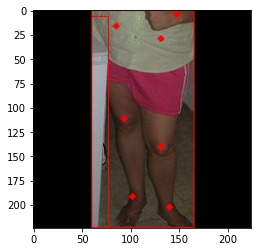

In [36]:
WIDTH = 224
HEIGHT = 224
for i in range(len(keypoints_df)):
    
    row = keypoints_df.iloc[i]

    img = cv2.imread(os.path.join(IMGS_DIR, row['file_name']))

    new_img, kp, (left, top, resize_ratio) = preprocess(img, row['keypoints'], WIDTH=WIDTH, HEIGHT=HEIGHT)
    
    row['height'], row['width'] = new_img.shape[:2]
    row['keypoints'] = kp
    
    bbox_rows = copy.deepcopy(bbox_df[bbox_df['image_id'] == row['id']])
    
    test_img = new_img.copy()

    for j in bbox_rows.index:
        _brow = bbox_rows.loc[j]
        _bbox = _brow['bbox']
        _bbox[0] = (_bbox[0] + left)*resize_ratio
        _bbox[1] = (_bbox[1] + top)*resize_ratio
        _bbox[2:] = (_bbox[2:]*resize_ratio).round().astype(int)
        new_bbox_df = new_bbox_df.append(_brow)
        test_img = plot_bbox(test_img, _bbox)
    
    plt.imsave(os.path.join(DIR_FOR_NEW_IMGS, row['file_name']), rgb(new_img))
    new_df = new_df.append(row)
    
    clear_output(wait=True)
    print(f'{i+1} of {len(keypoints_df)}')
    plt.imshow(rgb(draw_kp_on_image(test_img, kp, lines=False)))
    plt.show()
#     time.sleep(5)

In [52]:
new_df['keypoints'] = new_df['keypoints'].apply(lambda x: json.dumps(list(map(to_int, x.reshape(-1,)))).replace(',', '-'))
new_bbox_df['bbox'] = new_bbox_df['bbox'].apply(lambda x: json.dumps(list(map(to_int, x.reshape(-1,)))).replace(',', '-'))

In [55]:
new_df.to_csv(os.path.join(DIR_FOR_NEW_DATA, 'keypoints.csv'))
new_bbox_df.to_csv(os.path.join(DIR_FOR_NEW_DATA, 'bbox.csv'))

In [84]:
new_df

,license,file_name,coco_url,height,width,date_captured,flickr_url,id,num_keypoints,keypoints,image_id,category_id,id_y
0,3.0,000000574769.jpg,http://images.cocodataset.org/train2017/000000...,224.0,224.0,2013-11-14 17:07:59,http://farm8.staticflickr.com/7010/6728227647_...,574769.0,8.0,[174- 0- 0- 54- 29- 0- 141- 21- 2- 87- 19- 2- ...,574769.0,1.0,201078.0
1,3.0,000000483108.jpg,http://images.cocodataset.org/train2017/000000...,224.0,224.0,2013-11-14 18:27:53,http://farm3.staticflickr.com/2012/2087034507_...,483108.0,8.0,[172- 0- 0- 54- 0- 0- 128- 34- 2- 80- 34- 2- 1...,483108.0,1.0,188213.0
2,1.0,000000463836.jpg,http://images.cocodataset.org/train2017/000000...,224.0,224.0,2013-11-15 12:18:57,http://farm4.staticflickr.com/3292/2733229050_...,463836.0,8.0,[89- 25- 2- 151- 28- 2- 98- 28- 2- 139- 24- 2-...,463836.0,1.0,441196.0
3,2.0,000000369826.jpg,http://images.cocodataset.org/train2017/000000...,224.0,224.0,2013-11-15 23:01:04,http://farm3.staticflickr.com/2859/8929261675_...,369826.0,8.0,[32- 32- 0- 122- 32- 0- 64- 79- 2- 81- 75- 2- ...,369826.0,1.0,1241029.0
4,1.0,000000291380.jpg,http://images.cocodataset.org/train2017/000000...,224.0,224.0,2013-11-16 00:11:22,http://farm4.staticflickr.com/3120/2760079876_...,291380.0,8.0,[95- 29- 0- 14- 29- 0- 103- 71- 2- 63- 73- 2- ...,291380.0,1.0,219822.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
150918,2.0,522234.jpg,http://images.cocodataset.org/train2017/000000...,224.0,224.0,2013-11-21 03:42:29,http://farm8.staticflickr.com/7193/6788210866_...,569560.0,8.0,[3- 0- 0- 3- 0- 0- 103- 26- 2- 61- 30- 2- 133-...,569560.0,1.0,522234.0
151136,1.0,503135.jpg,http://images.cocodataset.org/train2017/000000...,224.0,224.0,2013-11-22 14:55:29,http://farm9.staticflickr.com/8292/7847738432_...,194663.0,8.0,[164- 0- 0- 142- 4- 2- 145- 44- 2- 113- 42- 2-...,194663.0,1.0,503135.0
151715,5.0,231259.jpg,http://images.cocodataset.org/train2017/000000...,224.0,224.0,2013-11-14 23:09:40,http://farm1.staticflickr.com/56/150748594_342...,142014.0,8.0,[166- 10- 2- 52- 4- 1- 147- 35- 2- 110- 31- 2-...,142014.0,1.0,231259.0
151886,1.0,464037.jpg,http://images.cocodataset.org/train2017/000000...,224.0,224.0,2013-11-16 16:51:17,http://farm1.staticflickr.com/13/94345708_87e5...,324332.0,8.0,[139- 0- 0- 124- 55- 2- 120- 25- 2- 103- 32- 2...,324332.0,1.0,464037.0


## Test

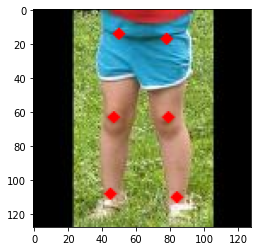

In [186]:
row = new_df.iloc[88]
img = cv2.imread(os.path.join(TRAINING_DIR, 'all', row['file_name']))
# new_img, kp = preprocess(img, row['keypoints'], WIDTH=128, HEIGHT=128)

# plt.subplot(121)
plt.imshow(rgb(draw_kp_on_image(img, row['keypoints'], lines=False)))
# plt.subplot(122)
# plt.imshow(rgb(draw_kp_on_image(new_img, kp, lines=False)))
plt.show()

# Rough

In [192]:
row['keypoints']

array([[102,   0,   0],
       [ 35,   0,   0],
       [ 78,  17,   2],
       [ 50,  14,   2],
       [ 79,  63,   2],
       [ 47,  63,   2],
       [ 84, 110,   2],
       [ 45, 108,   2]])

In [81]:
def plot_bbox(img, bbox):
    x1, y1, w, h = bbox

    x2, y2 = x1+w, y1+h

    p1 = (x1, y1)
    p2 = (x2, y1)
    p3 = (x1, y2)
    p4 = (x2, y2)

    bbox_img = cv2.line(img.copy(), p1, p2, color=(0,0,255), thickness=1)
    bbox_img = cv2.line(bbox_img, p2, p4, color=(0,0,255), thickness=1)
    bbox_img = cv2.line(bbox_img, p3, p4, color=(0,0,255), thickness=1)
    bbox_img = cv2.line(bbox_img, p1, p3, color=(0,0,255), thickness=1)

    return bbox_img

In [205]:
list(map(to_int, row['keypoints'].reshape(-1,))).__len__()

24

In [134]:
row = df.iloc[8]

In [135]:
WIDTH = 128
HEIGHT = 128

In [136]:
img = cv2.imread(os.path.join(ONE_PERSON_DIR, row['file_name']))

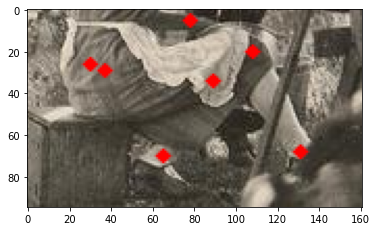

In [137]:
plt.imshow(rgb(draw_kp_on_image(img, row['keypoints'], lines=False)))

In [138]:
h, w = img.shape[:2]
h, w

(95, 161)

In [139]:
if w > h:
    pad = w - h
    img_by = w
else:
    pad = h - w
    img_by = h
pad

66

In [140]:
top, bottom, left, right = 0, img_by, 0, img_by
if w > h:
    top = int(np.ceil(pad/2)) + 1
    if pad > 1:
        bottom = img_by - int(np.floor(pad/2)) + 1
    else:
        top -= 1
else:
    left = int(np.ceil(pad/2)) + 1
    if pad > 1:
        right = img_by - int(np.floor(pad/2)) + 1
    else:
        left -= 1
'Padding', top, bottom, left, right

('Padding', 34, 129, 0, 161)

In [141]:
new_img = np.zeros((img_by, img_by, 3)).astype('uint8')

In [142]:
img.shape, new_img.shape

((95, 161, 3), (161, 161, 3))

In [143]:
new_img[top:bottom, left:right, :] = img

In [144]:
new_img = cv2.resize(new_img, (WIDTH, HEIGHT))

In [145]:
resize_ratio = min((WIDTH/w), (HEIGHT/h))
resize_ratio

0.7950310559006211

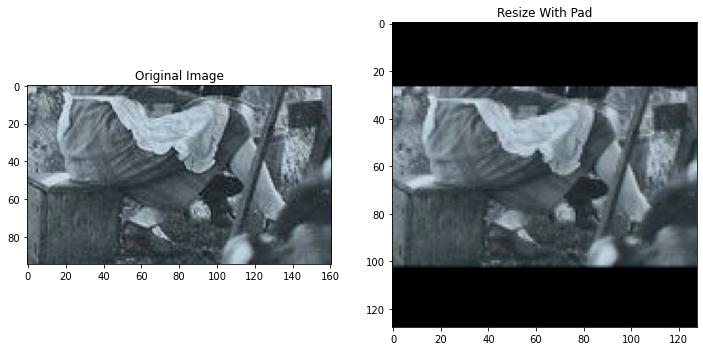

In [146]:
plt.figure(figsize=(12,12))

plt.subplot(121)
plt.title('Original Image')
plt.imshow(img)

plt.subplot(122)
plt.title('Resize With Pad')
plt.imshow(new_img)

In [147]:
kp = row['keypoints']

In [148]:
kp[:, 0] = (kp[:, 0] + left)*resize_ratio
kp[:, 1] = (kp[:, 1] + top)*resize_ratio

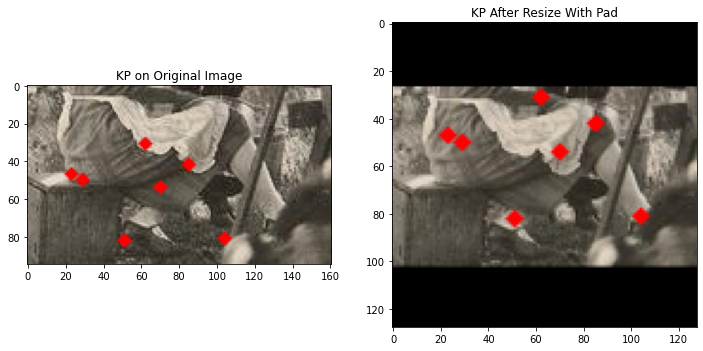

In [149]:
plt.figure(figsize=(12,12))

plt.subplot(121)
plt.title('KP on Original Image')
plt.imshow(rgb(draw_kp_on_image(img, row['keypoints'], lines=False)))

plt.subplot(122)
plt.title('KP After Resize With Pad')
plt.imshow(rgb(draw_kp_on_image(new_img, kp, lines=False)))